In [1]:
import numpy as np
import pandas as pd


In [4]:
a = pd.read_csv(r"D:\Python\TekWorks\Week_4\transactions.csv")
df = pd.DataFrame(a)

In [5]:
df.head()

,t_date,cust_id,t_amt,services,products_used,city,state,t_details
0,06-26-2015,4007024,40.33,Exercise & Fitness,Cardio Machine Accessories,Clarksville,Tennessee,credit
1,05-26-2015,4006742,198.44,Exercise & Fitness,Weightlifting Gloves,Long Beach,California,credit
2,06-01-2015,4009775,5.58,Exercise & Fitness,Weightlifting Machine Accessories,Anaheim,California,credit
3,06-05-2015,4002199,198.19,Gymnastics,Gymnastics Rings,Milwaukee,Wisconsin,credit
4,12-17-2015,4002613,98.81,Team Sports,Field Hockey,Nashville,Tennessee,credit


In [6]:
df.columns

Index(['t_date', 'cust_id', 't_amt', 'services', 'products_used', 'city',
       'state', 't_details'],
      dtype='str')

#     1.  Total Sales amount across all transactions


In [9]:
df.t_amt.sum()

np.float64(5110820.54)

# 2. Which month had the highest total transaction amount?


In [24]:
df['month'] = pd.to_datetime(df['t_date']).dt.month


In [32]:
a = df.groupby('month')['t_amt'].max()
idx = 1
for i in a:
    if a.max() == i:
        
        print(idx)
    idx+=1



6


# 3. What is the average transaction amount per customer?

In [28]:
df.groupby('cust_id')['t_amt'].mean()

cust_id
4000000    127.444000
4000001    108.945556
4000002     56.165000
4000003    123.670000
4000004    168.135000
              ...    
4009995     65.018571
4009996    104.515000
4009997    121.547500
4009998    110.950000
4009999     85.252500
Name: t_amt, Length: 9926, dtype: float64

# 4. What is the trend of total sales over months?


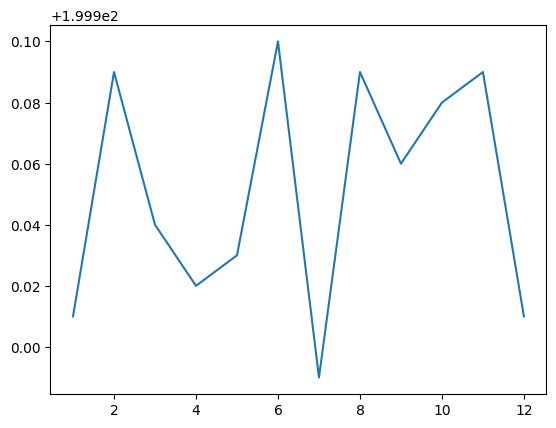

In [33]:
import matplotlib.pyplot as plt
plt.plot(a)

# 5. What is the highest single transaction amount recorded?


In [34]:
df['t_amt'].max()

np.float64(200.0)

In [35]:
df.columns

Index(['t_date', 'cust_id', 't_amt', 'services', 'products_used', 'city',
       'state', 't_details', 'month'],
      dtype='str')

# 6. Which service category contributes the most to total revenue?


In [40]:
a = df.groupby('services')['t_amt'].sum().idxmax()
a

'Outdoor Recreation'

In [41]:
df.head()

,t_date,cust_id,t_amt,services,products_used,city,state,t_details,month
0,06-26-2015,4007024,40.33,Exercise & Fitness,Cardio Machine Accessories,Clarksville,Tennessee,credit,6
1,05-26-2015,4006742,198.44,Exercise & Fitness,Weightlifting Gloves,Long Beach,California,credit,5
2,06-01-2015,4009775,5.58,Exercise & Fitness,Weightlifting Machine Accessories,Anaheim,California,credit,6
3,06-05-2015,4002199,198.19,Gymnastics,Gymnastics Rings,Milwaukee,Wisconsin,credit,6
4,12-17-2015,4002613,98.81,Team Sports,Field Hockey,Nashville,Tennessee,credit,12


# 7. Which product generated the highest revenue?

In [42]:
df.groupby('products_used')['t_amt'].sum().idxmax()

'Yoga & Pilates'

# 8. How does the average transaction amount vary between services?



In [43]:
df.groupby('services')['t_amt'].mean() - df['t_amt'].mean()

services
Air Sports                1.238693
Combat Sports            -1.154650
Dancing                   0.691101
Exercise & Fitness        1.443837
Games                     0.056557
Gymnastics                0.169490
Indoor Games              0.858273
Jumping                  -0.061240
Outdoor Play Equipment   -0.935215
Outdoor Recreation       -1.216931
Puzzles                  -1.620414
Racquet Sports            1.431050
Team Sports               0.522588
Water Sports             -0.316436
Winter Sports            -0.998693
Name: t_amt, dtype: float64

# 9. How many unique customers made purchases?

In [45]:
len(df['cust_id'].unique())

9926

# 10. Which customers have spent the most overall?

In [49]:
a = df.groupby('cust_id')['t_amt'].max().idxmax()
a

np.int64(4005620)